# DA5401W — Data Analytics Lab
## Tutorial: Regression - I &nbsp;|&nbsp; Student Notebook

| Field | Details |
|---|---|
| **Course** | DA5401W — Data Analytics Lab |
| **Instructor** | Dr. Arun B Ayyar |
| **Tutorial** | Regression - I |
| **Student Name** | *(fill in your name)* |
| **Roll Number** | *(fill in your roll number)* |
| **Date** | *(fill in today's date)* |

---

### Topics Covered
1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Regression
4. Logarithmic Regression
5. Effect of Parameters on Gradient Descent

> **Instructions:** Complete all code cells marked with `# TODO`. Do **not** modify cells marked with `# DO NOT MODIFY`. Answer all reflection questions in the provided Markdown cells.

---


## Imports and Setup

Run the cell below to import all required libraries.

In [ ]:
# DO NOT MODIFY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
np.random.seed(42)
print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## 1. Simple Linear Regression

### 1.1 Theory

**Simple Linear Regression** models the relationship between one independent variable $x$ and a dependent variable $y$:

$$\hat{y} = \beta_0 + \beta_1 x$$

The **Ordinary Least Squares (OLS)** closed-form solution minimises the Residual Sum of Squares:

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}, \qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

**Evaluation Metrics:**

| Metric | Formula | Interpretation |
|---|---|---|
| MSE | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | Average squared error; lower is better |
| RMSE | $\sqrt{\text{MSE}}$ | Same units as $y$; lower is better |
| $R^2$ | $1 - \frac{\text{RSS}}{\text{TSS}}$ | Proportion of variance explained; closer to 1 is better |

---


### 1.2 Dataset — Study Hours vs Exam Score

The dataset below records the number of study hours and corresponding exam scores for 10 students.

In [ ]:
# DO NOT MODIFY
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
scores = np.array([35, 42, 57, 61, 72, 78, 83, 88, 92, 97], dtype=float)

df_slr = pd.DataFrame({'Study_Hours': hours, 'Exam_Score': scores})
print(df_slr.to_string(index=False))


 Study_Hours  Exam_Score
         1.0        35.0
         2.0        42.0
         3.0        57.0
         4.0        61.0
         5.0        72.0
         6.0        78.0
         7.0        83.0
         8.0        88.0
         9.0        92.0
        10.0        97.0


### 1.3 Exercise — OLS Manual Calculation

**Task:** Compute the OLS estimates $\beta_0$ and $\beta_1$ manually using the formulas above.


In [ ]:
# steps :
# 1.Compute the mean of hours and scores
# 2. compute beta_0 and beta_1

# 1.Compute the mean of hours and scores
x_bar = np.mean(hours)
y_bar = np.mean(scores)

# 2. beta_0 and beta_1
beta_1 = np.sum((hours-x_bar)*(scores-y_bar))/np.sum((hours-x_bar)**2)
beta_0 = y_bar - beta_1 * x_bar

print(f"intercept : {round(beta_0,2)}")
print(f"slope : {round(beta_1,2)}")

intercept : 32.67
slope : 6.88


In [ ]:
# TODO: Compute the mean of hours and scores
# # x_bar = __
# # y_bar = __

# x_bar = np.mean(hours)
# y_bar = np.mean(scores)


# # TODO: Compute β₁ using the OLS formula
# # beta_1 = __
# beta_1 = np.sum((hours-x_bar)*(scores-y_bar))/np.sum((hours-x_bar)**2)

# # TODO: Compute β₀
# # beta_0 = __
# beta_0 = y_bar-beta_1*x_bar

# print(f"Intercept  β₀ = {beta_0:.4f}")
# print(f"Slope      β₁ = {beta_1:.4f}")
# print(f"Model : ŷ = {beta_0:.2f} + {beta_1:.2f}·x")


Intercept  β₀ = 32.6667
Slope      β₁ = 6.8788
Model : ŷ = 32.67 + 6.88·x


### 1.4 Exercise — Fit with scikit-learn and Evaluate

**Task:** Use `LinearRegression` from scikit-learn to fit the model and compute MSE, RMSE, and $R^2$.


In [ ]:
# steps :
# 1. Reshape hours to a 2-D array (required by sklearn)
# 2. Create a LinearRegression object and fit it
# 3. Generate predictions
# 4. Compute MSE, RMSE, and R²

# 1. Reshape hours to a 2-D array (required by sklearn)
X_slr = hours.reshape(-1,1)

# 2. Create a LinearRegression object and fit it
model_slr = LinearRegression()
model_slr.fit(X_slr,scores)

# 3. Generate predictions
y_pred_slr = model_slr.predict(X_slr)

# 4. Compute MSE, RMSE, and R²
mse = mean_squared_error(scores,y_pred_slr)
rmse = np.sqrt(mse)
r2 = r2_score(scores,y_pred_slr)

print(f"intercept : {model_slr.intercept_:.2f}")
print(f"slope :{model_slr.coef_[0]:.2f}")
print(f"MSE : {mse:.2f}")
print(f"rmse : {rmse:.2f}")
print(f"r2_score : {r2:.2f}")

intercept : 32.67
slope :6.88
MSE : 12.68
rmse : 3.56
r2_score : 0.97


In [ ]:
# # TODO: Reshape hours to a 2-D array (required by sklearn)
# # X_slr = __
# X_slr = hours.reshape(-1,1)

# # TODO: Create a LinearRegression object and fit it
# # model_slr = __
# # model_slr.fit(__,__)

# model_slr = LinearRegression()
# model_slr.fit(X_slr,scores)

# # TODO: Generate predictions
# # y_pred_slr = __
# y_pred_slr = model_slr.predict(X_slr)

# # TODO: Compute MSE, RMSE, and R²
# # mse  = mean_squared_error(__,__)
# # rmse = np.sqrt(__)
# # r2   = r2_score(__,__)

# mse  = mean_squared_error(scores,y_pred_slr)
# rmse = np.sqrt(mse)
# r2   = r2_score(scores,y_pred_slr)

# print(f"sklearn  β₀ = {model_slr.intercept_:.4f}")
# print(f"sklearn  β₁ = {model_slr.coef_[0]:.4f}")
# print(f"\nMSE  = {mse:.4f}")
# print(f"RMSE = {rmse:.4f}")
# print(f"R²   = {r2:.4f}")

sklearn  β₀ = 32.6667
sklearn  β₁ = 6.8788

MSE  = 12.6788
RMSE = 3.5607
R²   = 0.9685


In [ ]:
#help(np.reshape)

### 1.5 Exercise — Visualisation

**Task:** Create a scatter plot of the data with the regression line overlaid, and a residual plot.


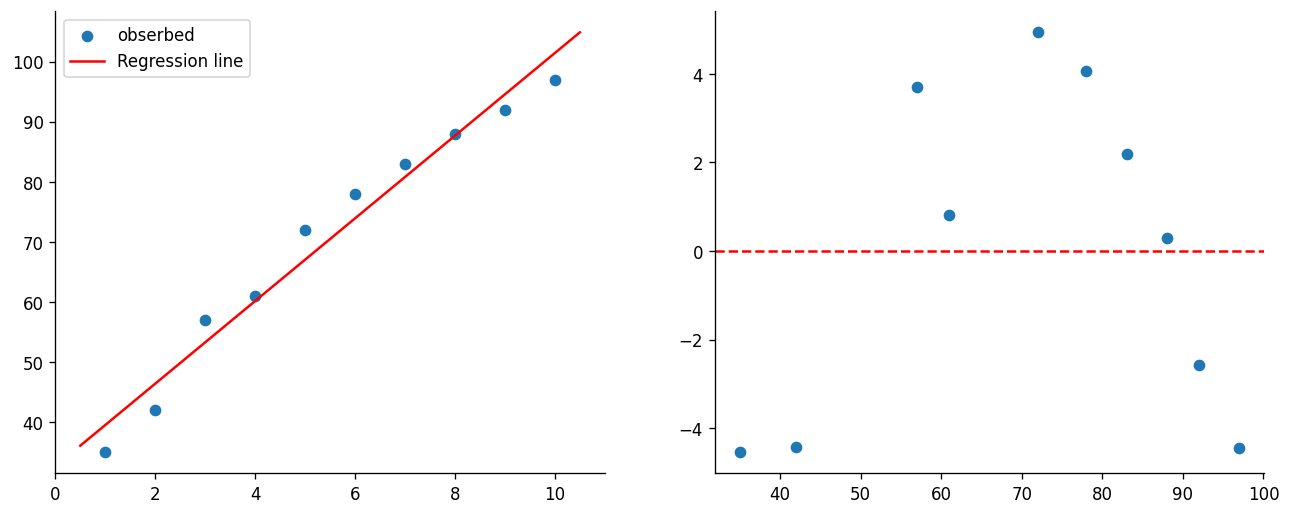

In [ ]:
# steps :
# 1 . Scatter + regression line
# 2.  Residual plot

fig,axes = plt.subplots(1,2,figsize=(13,5))

# 1 . Scatter + regression line
# original data scatter plot
axes[0].scatter(hours,scores,label = 'obserbed')
# regression line :(use x values from 0.5 to 10.5)
x_line = np.linspace(0.5,10.5,200)
axes[0].plot(x_line,model_slr.predict(x_line.reshape(-1,1)),label='Regression line',color='red')
axes[0].legend()

# 2.  Residual plot
residuals = scores-y_pred_slr
axes[1].scatter(scores,residuals,label = 'residual plot')
axes[1].axhline(y=0,linestyle ='--',color='red')

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # ── Plot 1: Scatter + regression line ────────────────────────────────────────
# ax = axes[0]
# # TODO: Plot the scatter of hours vs scores
# ax.scatter(hours,scores, color='steelblue', s=80, zorder=3, label='Observed')

# # TODO: Plot the regression line (use x values from 0.5 to 10.5)
# x_line = np.linspace(0.5, 10.5, 200)
# # ax.plot(__,__, color='crimson', linewidth=2, label='Regression line')
# ax.plot(x_line,model_slr.predict(x_line.reshape(-1,1)), color='crimson', linewidth=2, label='Regression line')

# ax.set_xlabel('Study Hours')
# ax.set_ylabel('Exam Score')
# ax.set_title('Simple Linear Regression')
# ax.legend()

# # ── Plot 2: Residual plot ─────────────────────────────────────────────────────
# ax2 = axes[1]
# # TODO: Compute residuals
# # residuals = __
# residuals = scores-y_pred_slr

# ax2.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
# # TODO: Scatter fitted values vs residuals
# # ax2.scatter(__, __, color='steelblue', s=80)
# ax2.scatter(y_pred_slr, residuals, color='steelblue', s=80)
# ax2.set_xlabel('Fitted Values (ŷ)')
# ax2.set_ylabel('Residuals (y − ŷ)')
# ax2.set_title('Residual Plot')

# plt.tight_layout()
# plt.show()


In [ ]:
#help(plt.scatter)

### 1.6 Reflection Questions

Answer the following questions in this cell:

1. What does a positive slope $\beta_1$ indicate about the relationship between study hours and exam scores?

   *positive corrleation : the number of study hour is the better the performance.*

2. What does an $R^2$ value close to 1 imply?

   *goodness of fit i.e. model is haveing best fit line .*

3. What pattern in the residual plot would indicate that a linear model is **not** appropriate?

   *Funnel shape (heteroscedasticity) : Non-constant variance*

---


---
## 2. Multiple Linear Regression

### 2.1 Theory

**Multiple Linear Regression (MLR)** extends simple linear regression to $p$ predictors:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

The OLS estimator in matrix form is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Key Assumptions of MLR:**

| Assumption | Description |
|---|---|
| Linearity | $y$ is a linear function of the predictors |
| Independence | Observations are independent |
| Homoscedasticity | Constant variance of residuals |
| Normality | Residuals are normally distributed |
| No multicollinearity | Predictors are not perfectly correlated |

---


### 2.2 Dataset — House Price Prediction

The dataset contains three features: `Area_sqft`, `Bedrooms`, and `Age_years`, with `Price_lakh` as the target.

In [ ]:
# DO NOT MODIFY
np.random.seed(0)
n = 120
area       = np.random.uniform(500, 3500, n)
bedrooms   = np.random.randint(1, 6, n).astype(float)
age        = np.random.uniform(0, 40, n)
price      = 50 + 0.12*area + 8*bedrooms - 1.5*age + np.random.normal(0, 15, n)

df_mlr = pd.DataFrame({
    'Area_sqft': area,
    'Bedrooms' : bedrooms,
    'Age_years': age,
    'Price_lakh': price
})

print("Dataset shape:", df_mlr.shape)
print("\nFirst 5 rows:")
print(df_mlr.head().to_string(index=False))
print("\nDescriptive statistics:")
print(df_mlr.describe().round(2).to_string())


Dataset shape: (120, 4)

First 5 rows:
  Area_sqft  Bedrooms  Age_years  Price_lakh
2146.440512       5.0  15.338556  343.150342
2645.568099       2.0  23.532685  321.397087
2308.290128       4.0  33.241938  297.189120
2134.649549       2.0  25.159274  263.410916
1770.964398       1.0  34.906026  215.391430

Descriptive statistics:
       Area_sqft  Bedrooms  Age_years  Price_lakh
count     120.00    120.00     120.00      120.00
mean     1990.68      2.98      19.60      281.49
std       858.71      1.39      12.05      106.46
min       514.09      1.00       0.46       72.36
25%      1256.47      2.00       9.19      194.50
50%      2110.67      3.00      19.28      298.03
75%      2610.22      4.00      30.86      356.44
max      3465.12      5.00      39.27      492.76


### 2.3 Exercise — Train/Test Split and Model Fitting

**Task:** Split the data (80/20), fit a `LinearRegression` model, and evaluate on both train and test sets.


In [ ]:
# Define feature matrix X and target vector y
x_mlr = df_mlr[['Area_sqft','Bedrooms','Age_years']].values
y_mlr = df_mlr['Price_lakh'].values

# Split into train and test sets (test_size=0.2, random_state=42)
X_train,X_test , y_train,y_test = train_test_split(x_mlr,y_mlr,test_size = 0.2,random_state=42)

# Fit the model
model_mlr = LinearRegression()
model_mlr.fit(X_train,y_train)

# Generate predictions for train and test sets
y_pred_train = model_mlr.predict(X_train)
y_pred_test = model_mlr.predict(X_test)

# Print R² and RMSE for train and test
train_rmse = np.sqrt(mean_squared_error(y_train,y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test,y_pred_test))

train_r2 = r2_score(y_train,y_pred_train)
test_r2 = r2_score(y_test,y_pred_test)

print(f"train_rmse : {train_rmse:.2f}")
print(f"test_rmse : {test_rmse:.2f}")

print(f"train_r2 :{train_r2:.2f}")
print(f"test_r2 :{test_r2:.2f}")

for name , coeff in zip(['Area_sqft','Bedrooms','Age_years'],model_mlr.coef_):
    print(f"{name} : {coeff:.2f}")
print(f"intercept : {model_mlr.intercept_:.2f}")


train_rmse : 14.72
test_rmse : 10.26
train_r2 :0.98
test_r2 :0.99
Area_sqft : 0.12
Bedrooms : 9.99
Age_years : -1.70
intercept : 46.37


In [ ]:
# TODO: Define feature matrix X and target vector y
# TODO: Split into train and test sets (test_size=0.2, random_state=42)
# TODO: Fit the model
# TODO: Generate predictions for train and test sets
# TODO: Print R² and RMSE for train and test

# TODO: Define feature matrix X and target vector y
X_mlr = df_mlr[['Area_sqft','Bedrooms','Age_years']].values
y_mlr = df_mlr['Price_lakh'].values

# TODO: Split into train and test sets (test_size=0.2, random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X_mlr,y_mlr,test_size=0.2,random_state=42)

# TODO: Fit the model
model_mlr = LinearRegression()
model_mlr.fit(X_train,y_train)

# TODO: Generate predictions for train and test sets
y_pred_train = model_mlr.predict(X_train)
y_pred_test  = model_mlr.predict(X_test)

print("Coefficients:")

for name , coef in zip(['Area_sqft','Bedrooms','Age_years'],model_mlr.coef_):
    print(f"  β({name:12s}) = {coef:.4f}")
print(f"  β₀ (intercept)  = {model_mlr.intercept_}")

print(f"\nTrain  R² = {r2_score(y_train, y_pred_train):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"\nTest  R² = {r2_score(y_test, y_pred_test):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

Coefficients:
  β(Area_sqft   ) = 0.1197
  β(Bedrooms    ) = 9.9866
  β(Age_years   ) = -1.6994
  β₀ (intercept)  = 46.36698654299519

Train  R² = 0.9815  |  RMSE = 14.7172

Train  R² = 0.9878  |  RMSE = 10.2598


In [ ]:
# # TODO: Define feature matrix X and target vector y
# X_mlr = df_mlr[___].values
# y_mlr = df_mlr[___].values

# # TODO: Split into train and test sets (test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(___,__, test_size=0.8, random_state=42)

# # TODO: Fit the model
# model_mlr = LinearRegression()
# model_mlr.fit(___, ___)

# # TODO: Generate predictions for train and test sets
# y_pred_train = ___
# y_pred_test  = ___

# print("Coefficients:")
# for name, coef in zip(['Area_sqft', 'Bedrooms', 'Age_years'], model_mlr.coef_):
#     print(f"  β({name:12s}) = {coef:.4f}")
# print(f"  β₀ (intercept)  = {model_mlr.intercept_:.4f}")

# # TODO: Print R² and RMSE for train and test
# print(f"\nTrain  R² = {r2_score(y_train, y_pred_train):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
# print(f"Test   R² = {r2_score(y_test,  y_pred_test ):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test,  y_pred_test )):.4f}")


### 2.4 Exercise — Visualisation

**Task:** Plot (a) actual vs predicted values on the test set, and (b) a bar chart of feature coefficients.


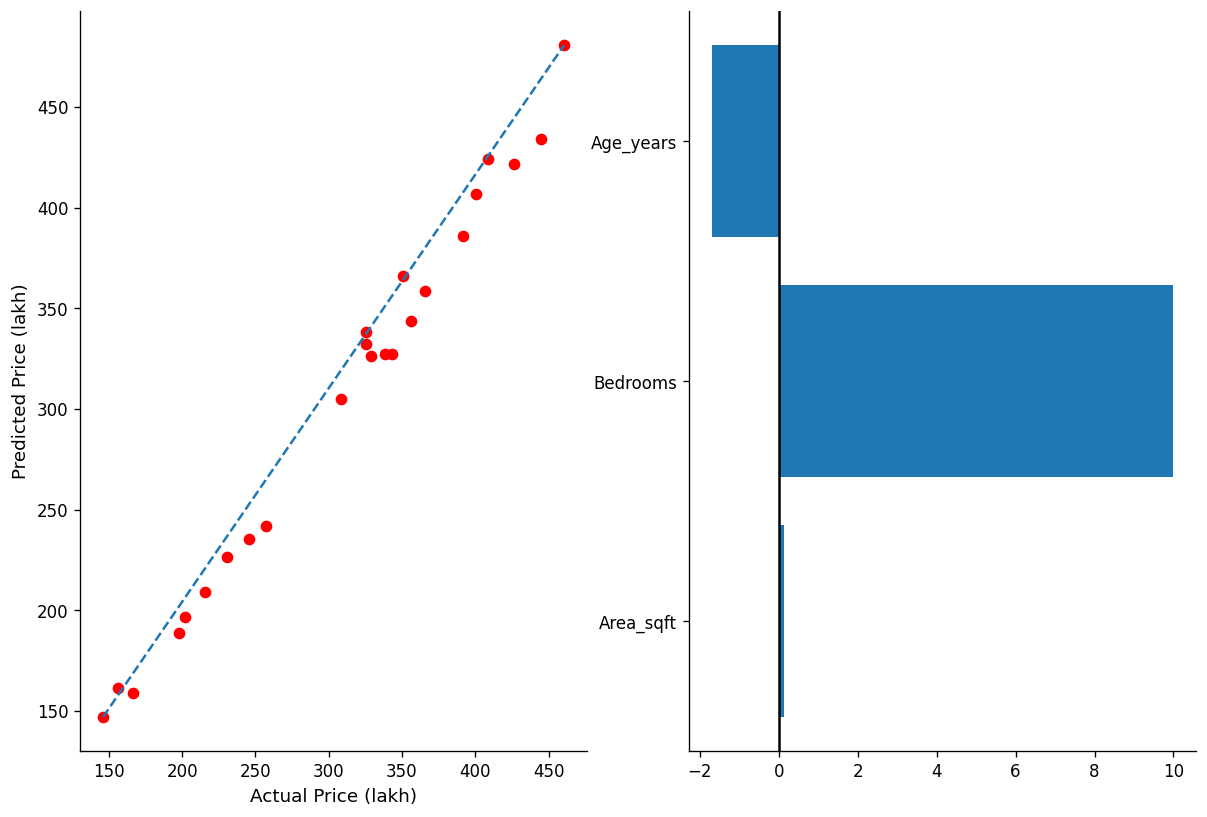

In [ ]:
# Scatter y_test vs y_pred_test
fig,axes = plt.subplots(1,2,figsize=(12,8))
axes[0].scatter(y_test,y_pred_test,color='red')
axes[0].set_xlabel('Actual Price (lakh)')
axes[0].set_ylabel('Predicted Price (lakh)')
axes[0].plot([min(y_test),max(y_test)],[min(y_pred_test),max(y_pred_test)],linestyle='dashed')

# Plot 2: Feature Coefficients
axes[1].barh(['Area_sqft','Bedrooms','Age_years'],model_mlr.coef_)
axes[1].axvline(0,color='black')

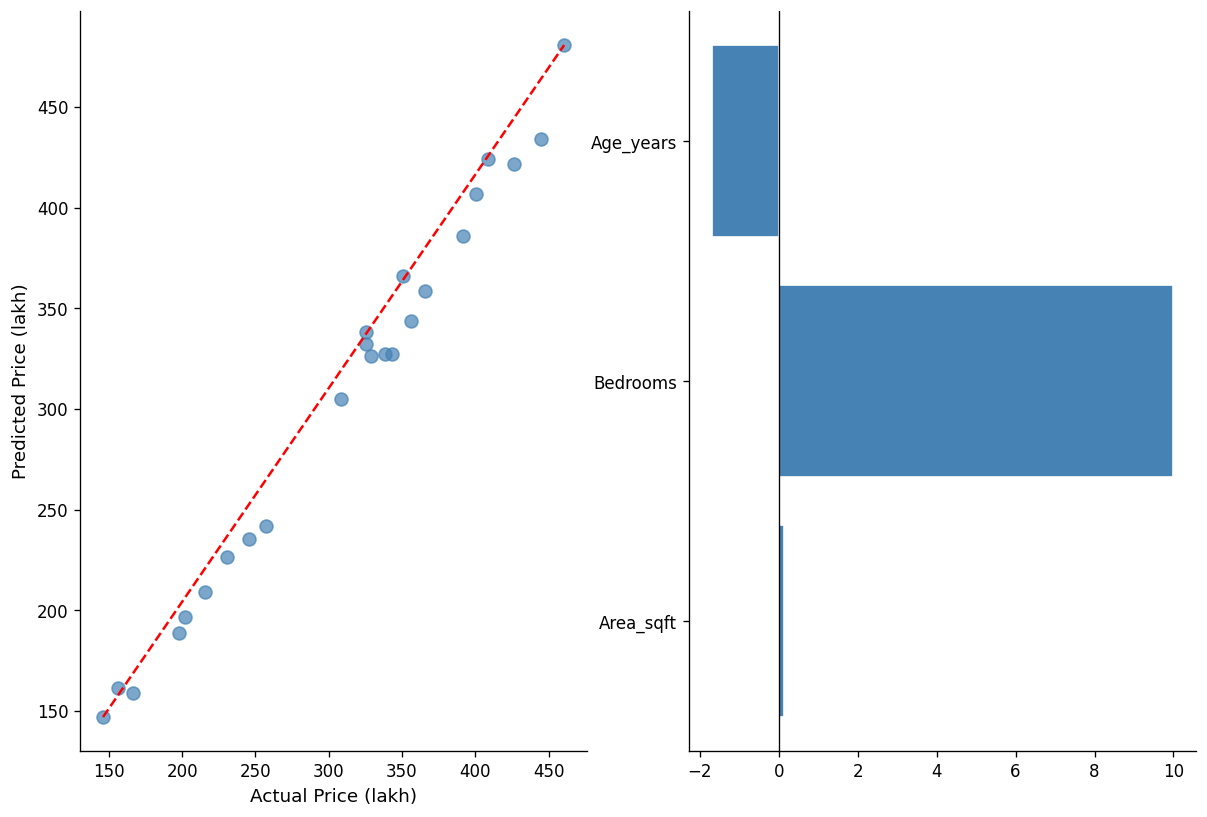

In [ ]:
# TODO: Scatter y_test vs y_pred_test
# Plot 2: Feature Coefficients

# TODO: Scatter y_test vs y_pred_test
fig,axes = plt.subplots(1,2,figsize=(12,8))
axes[0].scatter(y_test,y_pred_test,color='steelblue',alpha=0.7,s=60, label = 'test set')
axes[0].plot([min(y_test),max(y_test)],[min(y_pred_test),max(y_pred_test)],linestyle = 'dashed',linewidth=1.5,label = 'perfect prediction',color='red')
axes[0].set_xlabel('Actual Price (lakh)')
axes[0].set_ylabel('Predicted Price (lakh)')

# Plot 2: Feature Coefficients
features = ['Area_sqft', 'Bedrooms', 'Age_years']
axes[1].barh(features,model_mlr.coef_,color='steelblue',edgecolor='white')
axes[1].axvline(0,color='black',linewidth=0.8)


In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # ── Plot 1: Actual vs Predicted ───────────────────────────────────────────────
# ax = axes[0]
# # TODO: Scatter y_test vs y_pred_test
# ax.scatter(___, ___, color='steelblue', alpha=0.7, s=60, label='Test set')

# # TODO: Draw a diagonal line representing perfect prediction
# lims = [min(y_test.min(), y_pred_test.min())-5,
#         max(y_test.max(), y_pred_test.max())+5]
# ax.plot(___, ___, 'r--', linewidth=1.5, label='Perfect prediction')
# ax.set_xlabel('Actual Price (lakh)')
# ax.set_ylabel('Predicted Price (lakh)')
# ax.set_title('MLR — Actual vs Predicted')
# ax.legend()

# # ── Plot 2: Feature Coefficients ──────────────────────────────────────────────
# ax2 = axes[1]
# features = ['Area_sqft', 'Bedrooms', 'Age_years']
# # TODO: Plot a horizontal bar chart of model_mlr.coef_
# ax2.barh(___, ___, color='steelblue', edgecolor='white')
# ax2.axvline(0, color='black', linewidth=0.8)
# ax2.set_xlabel('Coefficient Value')
# ax2.set_title('Feature Coefficients')

# plt.tight_layout()
# plt.show()

### 2.5 Reflection Questions

1. Which feature has the largest positive effect on house price? Does this make intuitive sense?

   *bedrooms , no to make sense it must be coeffienct of scaled feature*

2. What does a negative coefficient for `Age_years` imply?

   *negative correlation*

3. If train $R^2$ is much higher than test $R^2$, what problem might this indicate?

   *underfitting , model is having high bias*

---


---
## 3. Polynomial Regression

### 3.1 Theory

**Polynomial Regression** fits a polynomial of degree $d$ to the data:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

The model is still **linear in the parameters**, so OLS applies after expanding features using `PolynomialFeatures`.

**Bias-Variance Trade-off:**

| Degree | Bias | Variance | Risk |
|---|---|---|---|
| Too low (e.g., 1) | High | Low | Underfitting |
| Appropriate | Balanced | Balanced | Good generalisation |
| Too high (e.g., 15+) | Low | High | Overfitting |

---


### 3.2 Dataset — Temperature vs Ice Cream Sales

In [ ]:
# DO NOT MODIFY
np.random.seed(7)
temp  = np.linspace(5, 40, 60)
sales = -0.5*temp**2 + 25*temp - 100 + np.random.normal(0, 20, 60)

df_poly = pd.DataFrame({'Temperature_C': temp, 'IceCream_Sales': sales})
print("Dataset shape:", df_poly.shape)
print(df_poly.head().to_string(index=False))

Dataset shape: (60, 2)
 Temperature_C  IceCream_Sales
      5.000000       46.310514
      5.593220       14.869704
      6.186441       36.181396
      6.779661       54.659949
      7.372881       41.363884


### 3.3 Exercise — Fit Polynomials of Degrees 1, 2, and 5

**Task:** For each degree in `[1, 2, 5]`, use `PolynomialFeatures` to expand the features, fit a `LinearRegression`, and record $R^2$ and RMSE.


In [ ]:
# steps :
# 1. define training the pipeline
from sklearn.pipeline import Pipeline
X_poly = temp.reshape(-1,1)
degrees = [1,2,3]
train_mse = {}

# training the pipeline
for degree in degrees:
    model = Pipeline([('poly', PolynomialFeatures(degree=degree,include_bias=True)),
                      ('linear',LinearRegression())])
    model.fit(X_poly,sales)
    y_pred = model.predict(X_poly)
    train_mse[f'degree {degree}'] = {"remse" : float(np.sqrt(mean_squared_error(sales,y_pred))),"r2": float(r2_score(sales,y_pred))}
train_mse

{'degree 1': {'remse': 49.14609971476162, 'r2': 0.22564881963167394},
 'degree 2': {'remse': 20.926420668860704, 'r2': 0.8596056105560519},
 'degree 3': {'remse': 20.908655479708532, 'r2': 0.8598438810414243}}

In [ ]:
_# help(PolynomialFeatures)

In [ ]:
from sklearn.pipeline import Pipeline
X_poly = temp.reshape(-1, 1)
degrees = [1, 2, 5]
train_mse = {}

#training the pipeline
for degree in degrees:
    model = Pipeline([('poly', PolynomialFeatures(degree,include_bias=False)),
                      ('linear',LinearRegression())])
    model.fit(X_poly,sales)
    y_pred = model.predict(X_poly)
    train_mse[degree] = {'RMSE': np.sqrt(mean_squared_error(sales,y_pred)),'R2':r2_score(sales,y_pred)}
train_mse

{1: {'RMSE': np.float64(49.14609971476162), 'R2': 0.22564881963167394},
 2: {'RMSE': np.float64(20.92642066886071), 'R2': 0.8596056105560517},
 5: {'RMSE': np.float64(20.83135274683979), 'R2': 0.8608783256198383}}

In [ ]:
# X_poly = temp.reshape(-1, 1)
# degrees = [1, 2, 5]
# models_poly  = {}
# metrics_poly = {}

# for d in degrees:
#     # TODO: Create PolynomialFeatures of degree d (include_bias=False)
#     pf = PolynomialFeatures(degree=___, include_bias=___)

#     # TODO: Fit-transform X_poly
#     X_d = pf.fit_transform(___)

#     # TODO: Fit a LinearRegression model
#     m = LinearRegression()
#     m.fit(___, ___)

#     # TODO: Generate predictions
#     y_hat = m.predict(___)

#     models_poly[d] = (pf, m)
#     metrics_poly[d] = {
#         'R2'  : r2_score(sales, y_hat),
#         'RMSE': np.sqrt(mean_squared_error(sales, y_hat))
#     }

# print(f"{'Degree':>8} | {'R²':>8} | {'RMSE':>8}")
# print("-" * 32)
# for d in degrees:
#     print(f"{d:>8} | {metrics_poly[d]['R2']:>8.4f} | {metrics_poly[d]['RMSE']:>8.4f}")


### 3.4 Exercise — Visualise Degree Comparison

**Task:** Plot the fitted curves for each degree side by side.


In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
# colors_d = {1: 'crimson', 2: 'seagreen', 5: 'darkorange'}
# labels_d = {1: 'Degree 1 (Linear)', 2: 'Degree 2 (Quadratic)', 5: 'Degree 5'}

# x_plot = np.linspace(temp.min()-1, temp.max()+1, 300).reshape(-1, 1)

# for ax, d in zip(axes, degrees):
#     pf, m = models_poly[d]
#     # TODO: Generate predictions over x_plot using the stored (pf, m) pair
#     y_line = m.predict(pf.transform(___))

#     ax.scatter(temp, sales, color='steelblue', s=30, alpha=0.7, label='Data')
#     ax.plot(x_plot, y_line, color=colors_d[d], linewidth=2, label=labels_d[d])
#     ax.set_xlabel('Temperature (°C)')
#     ax.set_title(f'{labels_d[d]}\nR² = {metrics_poly[d]["R2"]:.3f}  RMSE = {metrics_poly[d]["RMSE"]:.2f}')
#     ax.legend(fontsize=8)

# axes[0].set_ylabel('Ice Cream Sales')
# plt.suptitle('Polynomial Regression — Degree Comparison', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.show()

### 3.5 Exercise — Bias-Variance Demonstration

**Task:** Plot train and test RMSE for polynomial degrees 1 through 11 to visualise the bias-variance trade-off.


Text(0, 0.5, 'RMSE')

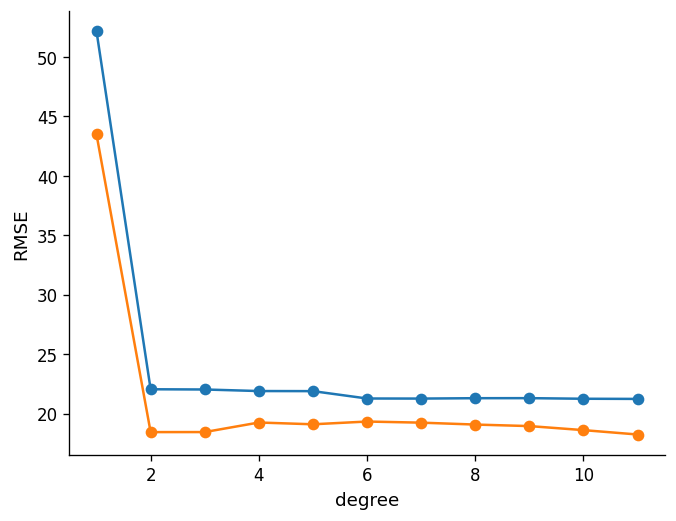

In [ ]:
from sklearn.pipeline import Pipeline
X_train,X_test,y_train,y_test = train_test_split(X_poly,sales,test_size=0.30,random_state=1)
train_mse = []
test_mse = []
poly_degree = range(1,12)
for degree in range(1,12):
    model = Pipeline([('ploy',PolynomialFeatures(degree,include_bias=False)),
                      ('linear',LinearRegression())])
    model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    train_mse.append(np.sqrt(mean_squared_error(y_train,y_pred_train)))
    test_mse.append(np.sqrt(mean_squared_error(y_test,y_pred_test)))

plt.plot(poly_degree,train_mse,label='train_mse',marker='o')
plt.plot(poly_degree,test_mse,label='test_mse',marker='o')
plt.xlabel('degree')
plt.ylabel('RMSE')

In [ ]:
# # TODO: Split data into train/test (test_size=0.3, random_state=1)
# X_tr, X_te, y_tr, y_te = train_test_split(___, ___, test_size=___, random_state=___)

# degree_range = range(1, 12)
# train_rmse, test_rmse = [], []

# for d in degree_range:
#     # TODO: Create PolynomialFeatures, transform train and test sets
#     pf  = PolynomialFeatures(degree=d, include_bias=False)
#     X_tr_d = pf.fit_transform(___)
#     X_te_d = pf.transform(___)

#     # TODO: Fit model and compute RMSE for train and test
#     m = LinearRegression()
#     m.fit(___, ___)
#     train_rmse.append(np.sqrt(mean_squared_error(___, m.predict(___))))
#     test_rmse.append( np.sqrt(mean_squared_error(___, m.predict(___))))

# plt.figure(figsize=(8, 5))
# plt.plot(list(degree_range), train_rmse, 'o-', color='steelblue', label='Train RMSE')
# plt.plot(list(degree_range), test_rmse,  's-', color='crimson',   label='Test RMSE')
# plt.xlabel('Polynomial Degree')
# plt.ylabel('RMSE')
# plt.title('Bias-Variance Trade-off in Polynomial Regression')
# plt.legend()
# plt.tight_layout()
# plt.show()


### 3.6 Reflection Questions

1. At which polynomial degree does the test RMSE start increasing? What does this indicate?

   *3*

2. Why does training RMSE always decrease as degree increases?

   *bias will be reduced in high polynomial*

3. How would you select the optimal degree in a real-world scenario?

   *on validation dataset in which we have lowest mse*

---


---
## 4. Logarithmic Regression

### 4.1 Theory

**Logarithmic Regression** models a diminishing-returns relationship:

$$\hat{y} = \beta_0 + \beta_1 \ln(x)$$

The key idea is a **variable transformation**: substitute $z = \ln(x)$ to linearise the model, then apply OLS.

**When to use logarithmic regression:**

| Scenario | Indicator |
|---|---|
| Rapid initial growth that levels off | Concave scatter plot |
| Percentage changes matter more than absolute | Economic / biological data |
| Skewed predictor distribution | Long right tail in $x$ |

---


### 4.2 Dataset — Advertising Spend vs Revenue

In [ ]:
# DO NOT MODIFY
np.random.seed(3)
ad_spend = np.linspace(1, 200, 80)
revenue  = 20 * np.log(ad_spend) + np.random.normal(0, 5, 80)

df_log = pd.DataFrame({'Ad_Spend_k': ad_spend, 'Revenue_lakh': revenue})
print("Dataset shape:", df_log.shape)
print(df_log.head().to_string(index=False))


### 4.3 Exercise — Fit the Logarithmic Model

**Task:** Apply the log transformation to `ad_spend`, then fit a `LinearRegression` model and evaluate it.


In [ ]:
# # TODO: Compute the natural logarithm of ad_spend and reshape to (n, 1)
# log_spend = ___

# # TODO: Fit a LinearRegression model
# model_log = LinearRegression()
# model_log.fit(___, ___)

# # TODO: Generate predictions
# y_pred_log = ___

# print(f"β₀ (intercept) = {model_log.intercept_:.4f}")
# print(f"β₁ (log coef)  = {model_log.coef_[0]:.4f}")
# print(f"\nModel : ŷ = {model_log.intercept_:.2f} + {model_log.coef_[0]:.2f} · ln(x)")

# # TODO: Compute and print R² and RMSE
# print(f"\nR²   = {r2_score(___, ___) :.4f}")
# print(f"RMSE = {np.sqrt(mean_squared_error(___, ___)):.4f}")


### 4.4 Exercise — Visualisation

**Task:** Plot the fitted logarithmic curve on the original scale, and the linearised relationship after the log transformation.


In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# x_line = np.linspace(0.5, 210, 400)

# # ── Plot 1: Original scale ────────────────────────────────────────────────────
# ax = axes[0]
# ax.scatter(ad_spend, revenue, color='steelblue', s=40, alpha=0.7, label='Observed')

# # TODO: Plot the fitted curve using model_log.intercept_ and model_log.coef_[0]
# ax.plot(x_line, ___, color='crimson', linewidth=2, label='Logarithmic fit')
# ax.set_xlabel('Ad Spend (₹k)')
# ax.set_ylabel('Revenue (₹ lakh)')
# ax.set_title('Logarithmic Regression (Original Scale)')
# ax.legend()

# # ── Plot 2: Log-transformed scale ────────────────────────────────────────────
# ax2 = axes[1]
# # TODO: Scatter ln(ad_spend) vs revenue
# ax2.scatter(___, revenue, color='steelblue', s=40, alpha=0.7, label='Observed')

# # TODO: Plot the OLS line on the log-transformed scale
# z_line = np.log(x_line)
# ax2.plot(z_line, ___, color='crimson', linewidth=2, label='OLS fit on ln(x)')
# ax2.set_xlabel('ln(Ad Spend)')
# ax2.set_ylabel('Revenue (₹ lakh)')
# ax2.set_title('After Log Transformation (Linearised)')
# ax2.legend()

# plt.tight_layout()
# plt.show()


### 4.5 Reflection Questions

1. Why does the scatter plot of revenue vs ad spend look concave?

   *Your answer:*

2. After the log transformation, the relationship becomes linear. What does this tell us about the original relationship?

   *If the relationship becomes linear after a log transformation of the predictor, it indicates that the original relationship was logarithmic (non-linear), with diminishing returns.*

3. What would happen if you applied a log transformation to a predictor that already has a linear relationship with $y$?

   *Applying a log transformation to a predictor that already has a linear relationship with  y distorts the linear relationship, leading to model misspecification, poorer fit, and patterned residuals.*

---


---
## 5. Effect of Parameters on Gradient Descent

### 5.1 Theory

**Gradient Descent** iteratively minimises a cost function $J(\boldsymbol{\theta})$:

$$\theta_j \leftarrow \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

For Mean Squared Error:

$$J(\theta_0, \theta_1) = \frac{1}{2n}\sum_{i=1}^{n}(\theta_0 + \theta_1 x_i - y_i)^2$$

**Key hyperparameters:**

| Parameter | Effect if Too Small | Effect if Too Large |
|---|---|---|
| Learning rate $\alpha$ | Slow convergence | Overshooting / divergence |
| Iterations | Premature stop | Unnecessary computation |
| Initial $\theta_0$ | May affect path (non-convex) | Same risk |

---


### 5.2 Dataset and Helper Functions

Run the cell below — it provides the dataset and the `gradient_descent` function you will use in the exercises.

In [ ]:
# DO NOT MODIFY
np.random.seed(10)
x_gd = np.linspace(0, 10, 50)
y_gd = 3.5 * x_gd + 7 + np.random.normal(0, 4, 50)

def compute_cost(theta0, theta1, x, y):
    n = len(y)
    y_hat = theta0 + theta1 * x
    return (1 / (2*n)) * np.sum((y_hat - y)**2)

def gradient_descent(x, y, theta0_init, theta1_init, alpha, n_iter):
    n = len(y)
    theta0, theta1 = theta0_init, theta1_init
    cost_history = []
    theta0_hist, theta1_hist = [theta0], [theta1]
    for _ in range(n_iter):
        y_hat = theta0 + theta1 * x
        grad0 = (1/n) * np.sum(y_hat - y)
        grad1 = (1/n) * np.sum((y_hat - y) * x)
        theta0 -= alpha * grad0
        theta1 -= alpha * grad1
        cost_history.append(compute_cost(theta0, theta1, x, y))
        theta0_hist.append(theta0)
        theta1_hist.append(theta1)
    return theta0, theta1, cost_history, theta0_hist, theta1_hist

print("Helper functions loaded.")


### 5.3 Exercise — Effect of Learning Rate

**Task:** Run gradient descent with four different learning rates `[0.001, 0.01, 0.05, 0.2]` for 300 iterations each, starting from $\theta_0 = 0, \theta_1 = 0$. Plot the cost history for each.


In [ ]:
alphas   = [0.001, 0.01, 0.05, 0.2]
n_iter   = 300
colors_a = ['steelblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(9, 5))

for alpha, col in zip(alphas, colors_a):
    # TODO: Run gradient_descent with theta0_init=0, theta1_init=0
    t0, t1, ch, _, _ = gradient_descent(___, ___, ___, ___, ___, ___)

    if not any(np.isnan(ch)):
        plt.plot(ch, color=col, linewidth=1.8, label=f'α = {alpha}')
    else:
        plt.plot([], [], color=col, label=f'α = {alpha} (diverged)')

plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.title('Cost vs Iterations for Different Learning Rates')
plt.ylim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()


### 5.4 Exercise — Effect of Number of Iterations

**Task:** For a fixed learning rate of 0.01, run gradient descent with `[10, 50, 100, 500]` iterations. Plot the fitted line for each case.


In [ ]:
iter_list   = [10, 50, 100, 500]
alpha_fixed = 0.01

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
x_line_gd = np.linspace(x_gd.min(), x_gd.max(), 200)

for ax, n_it in zip(axes.flatten(), iter_list):
    # TODO: Run gradient_descent starting from (0, 0) with alpha_fixed and n_it iterations
    t0, t1, _, _, _ = gradient_descent(___, ___, ___, ___, ___, ___)

    ax.scatter(x_gd, y_gd, color='steelblue', s=25, alpha=0.6, label='Data')
    # TODO: Plot the fitted line t0 + t1*x_line_gd
    ax.plot(x_line_gd, ___, color='crimson', linewidth=2,
            label=f'θ₀={t0:.2f}, θ₁={t1:.2f}')
    ax.set_title(f'Iterations = {n_it}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of Number of Iterations (α = {alpha_fixed})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 5.5 Exercise — Cost Surface and Gradient Descent Path

**Task:** Compute the cost surface over a grid of $\theta_0$ and $\theta_1$ values, then overlay the gradient descent trajectory.


In [ ]:
# TODO: Define grids for theta0 (range -10 to 20) and theta1 (range -1 to 8)
theta0_vals = np.linspace(___, ___, 100)
theta1_vals = np.linspace(___, ___, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# TODO: Compute the cost surface using compute_cost for each (t0, t1) pair
J_surface = np.array([[compute_cost(t0, t1, x_gd, y_gd)
                        for t0 in theta0_vals]
                       for t1 in theta1_vals])

# TODO: Run gradient_descent starting from (-5, 0) with alpha=0.01, n_iter=300
_, _, _, t0h, t1h = gradient_descent(___, ___, ___, ___, ___, ___)

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(T0, T1, J_surface, levels=40, cmap='viridis')
plt.colorbar(cp, ax=ax, label='Cost J(θ)')

# TODO: Plot the gradient descent path (t0h, t1h) as a white line
ax.plot(___, ___, 'w-o', markersize=3, linewidth=1.5, label='GD path')
ax.plot(t0h[0],  t1h[0],  'rs', markersize=8,  label='Start')
ax.plot(t0h[-1], t1h[-1], 'r*', markersize=12, label='End')
ax.set_xlabel('θ₀')
ax.set_ylabel('θ₁')
ax.set_title('Cost Surface Contour with Gradient Descent Path')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.6 Reflection Questions

1. What happens to the convergence speed when the learning rate is too small? Too large?

   *Your answer:*

2. Why does gradient descent always converge to the global minimum for linear regression (MSE loss)?

   *Your answer:*

3. How does the number of iterations affect the quality of the fitted model?

   *Your answer:*

4. In the cost surface contour plot, what does the shape of the contours tell you about the sensitivity of the cost to each parameter?

   *Your answer:*

---


---
## Summary

Complete the table below based on what you have learned in this tutorial:

| Topic | Key Formula | When to Use | One Limitation |
|---|---|---|---|
| Simple Linear Regression | | | |
| Multiple Linear Regression | | | |
| Polynomial Regression | | | |
| Logarithmic Regression | | | |
| Gradient Descent | | | |

---

## Submission Checklist

Before submitting, ensure that:

- [ ] All `# TODO` cells are completed and produce correct output.
- [ ] All reflection questions are answered.
- [ ] The summary table is filled in.
- [ ] The notebook runs from top to bottom without errors (**Kernel → Restart & Run All**).
- [ ] Your name and roll number are filled in at the top.

---
*DA5401W — Data Analytics Lab | Instructor: Dr. Arun B Ayyar | Tutorial: Regression - I*
